In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo generado
df = pd.read_csv("tendencias_calzado_mexico.csv", index_col="date", parse_dates=True)

# Media móvil a 8 semanas para eliminar ruido semanal y ver la tendencia real
df_smooth = df.rolling(window=8).mean()



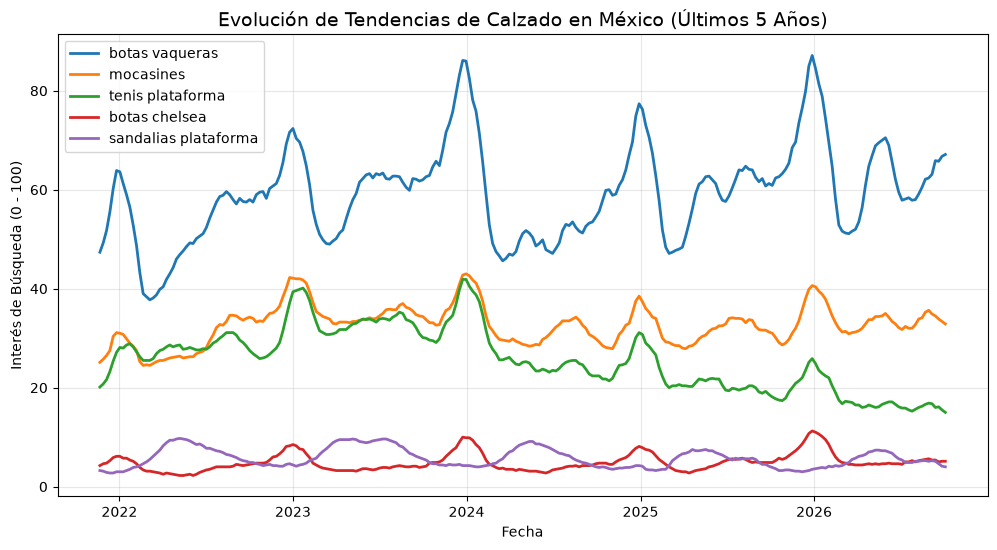

In [2]:
# Graficar
plt.figure(figsize=(12, 6))
for col in df_smooth.columns:
    plt.plot(df_smooth.index, df_smooth[col], label=col, linewidth=2)

plt.title("Evolución de Tendencias de Calzado en México (Últimos 5 Años)", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Interés de Búsqueda (0 - 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
import numpy as np

def diagnosticar_tendencias(df_suavizado):
    resultados = []
    
    # Tomamos las últimas 52 semanas (1 año) para evaluar la foto reciente
    df_reciente = df_suavizado.tail(52)
    
    for modelo in df_suavizado.columns:
        serie = df_suavizado[modelo]
        
        # 1. Valor actual vs valor hace 12 semanas (un trimestre)
        val_actual = serie.iloc[-1]
        val_hace_12w = serie.iloc[-12]
        cambio_trimestral = ((val_actual - val_hace_12w) / val_hace_12w) * 100
        
        # 2. Comparación interanual (mismo punto hace un año)
        val_hace_52w = serie.iloc[-52]
        cambio_anual = ((val_actual - val_hace_52w) / val_hace_52w) * 100
        
        # 3. Percentil actual respecto a su historia completa
        percentil_actual = (serie < val_actual).mean() * 100
        
        # 4. Clasificación de la regla
        if cambio_trimestral > 10 and cambio_anual > 0:
            estado = "🟢 En Crecimiento / Entrada de Temporada"
            accion = "Aumentar stock / Monitorear producción"
        elif cambio_trimestral < -10 and cambio_anual < -10:
            estado = "🔴 En Declive Sostenido"
            accion = "Reducir órdenes / Liquidar inventario"
        elif percentil_actual > 80:
            estado = "🟡 En Pico de Temporada"
            accion = "Cuidado con sobreinventario futuro"
        else:
            estado = "⚪ Estable / Fuera de Pico"
            accion = "Mantener producción base"
            
        resultados.append({
            "Modelo": modelo,
            "Nivel Actual (0-100)": round(val_actual, 1),
            "Cambio 3 Meses (%)": f"{cambio_trimestral:+.1f}%",
            "Cambio Anual (%)": f"{cambio_anual:+.1f}%",
            "Fase Actual": estado,
            "Recomendación Negocio": accion
        })
        
    return pd.DataFrame(resultados)

# Ejecutar diagnóstico
df_diagnostico = diagnosticar_tendencias(df_smooth)
df_diagnostico

,Modelo,Nivel Actual (0-100),Cambio 3 Meses (%),Cambio Anual (%),Fase Actual,Recomendación Negocio
0,botas vaqueras,67.1,+15.0%,+7.6%,🟢 En Crecimiento / Entrada de Temporada,Aumentar stock / Monitorear producción
1,mocasines,32.9,+2.7%,+9.1%,⚪ Estable / Fuera de Pico,Mantener producción base
2,tenis plataforma,15.0,-3.2%,-15.5%,⚪ Estable / Fuera de Pico,Mantener producción base
3,botas chelsea,5.1,+2.5%,-2.4%,⚪ Estable / Fuera de Pico,Mantener producción base
4,sandalias plataforma,4.0,-17.9%,+10.3%,⚪ Estable / Fuera de Pico,Mantener producción base
